# Life Expendancy Analysis

This notebook aims at taking a deep dive into the life expectancy dataset.

In [1]:
''' Necessary Imports '''
import ipykernel  # Jupyter notebook support (environment issues)
import pandas as pd  # Dataframe handling
import numpy as np  # Mathematical operations
import plotly.graph_objects as go  # Graphing/Interactive visualizations
import plotly.express as px  # Graphing/visualizations for world map
import missingno as msno  # For making a nullity matrix
import pycountry  # Deriving ISO-3 country codes
from sklearn.preprocessing import StandardScaler  # For standardizing numerical data
from sklearn.cluster import KMeans  # For k-Means clustering
from sklearn.metrics import silhouette_score  # For evaluating clustering performance
from sklearn.decomposition import PCA  # For dimensionality reduction (PCA)

## Problem 1: Loading and Initial Cleaning of the Data

Firstly, we must load the data from the provided Life Expectancy csv file, then perform the initial basic cleaning operations to strip leading/trailing whitespaces from column names.

In [2]:
# Load the dataset as a pandas dataframe
DATA_PATH: str = './data/Life Expectancy Data.csv'  # Path to the dataset
df = pd.read_csv(DATA_PATH)

# Strip all leading/trailing whitespaces from column names
df.columns = df.columns.str.strip()

# Verifying that all column names have been cleaned
print(df.columns)  # Directly print the columns
# Print if any column name has a leading or trailing whitespace
for col in df.columns:
    curCol = str(col)
    if curCol[0] == ' ' or curCol[-1] == ' ':
        print(f"Whitespace detected in column {curCol}")

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')


## Problem 2: Full Cleaning of the Data

In addition to stripping whitespace, the country entires are also not in standardized format. To fix this, we can map each country to a standard format using a defined dictionary.

In [3]:
# Defining a dictionary to rewrite each country into a standardized format
country_rewrite: dict = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Democratic Republic of the Congo': 'Congo, Democratic Republic of the',
    'Iran (Islamic Republic of)': 'Iran',
    'Micronesia (Federated States of)': 'Federated States of Micronesia',
    'Republic of Korea': 'South Korea',
    'Swaziland': 'Eswatini',
    'The former Yugoslav republic of Macedonia': 'Republic of North Macedonia',
    'Turkey': 'Türkiye',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
}

# Remapping each country name to the standardized format above
df['Country'].replace(country_rewrite, inplace=True)

country_rewrite_keys = country_rewrite.keys()

# Verify that all unstandardized country names have been replaced
unique_country_keys = df['Country'].unique()
if country_rewrite_keys not in unique_country_keys:
    print("Country keys rewritten successfully")
    # print(unique_country_keys)  # Extra validation
else:
    print("Country keys were not properly rewritten")

Country keys rewritten successfully


/tmp/ipykernel_3132/1046373722.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].replace(country_rewrite, inplace=True)


## Problem 3 - Initial Pre-processing

To further standardize the country names, we can also associate each country to it's ISO-3 country code.

In [4]:
# Brief helper function to fuzzy-search a given country name and return the ISO-3 code
def nameToISO3(country_name: str) -> str:
    try:
        if country_name == 'Congo, Democratic Republic of the': return 'COD'  # Special case handling
        return pycountry.countries.search_fuzzy(country_name)[0].alpha_3  # Fuzzy search for more versatile matching
    except LookupError:
        return np.nan  # Return a NaN so pandas treats it as missing

# Apply the helper function to each country value to make a new column representing ISO-3 codes
df['Country Code (ISO-3)'] = df['Country'].apply(nameToISO3)

# Verifying shape and unique country codes
print(df.shape)  # Print the dataframe shape to ensure consistency
print(df['Country Code (ISO-3)'].unique())  # Print unique country codes to ensure mapping
# Print any countries that were not properly mapped, if applicable
if df['Country Code (ISO-3)'].isna().any():
    print(f"Some country codes were not properly mapped: {df[df['Country Code (ISO-3)'].isna()]['Country'].unique()}")

(2938, 23)
['AFG' 'ALB' 'DZA' 'AGO' 'ATG' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BHS' 'BHR'
 'BGD' 'BRB' 'BLR' 'BEL' 'BLZ' 'BEN' 'BTN' 'BOL' 'BIH' 'BWA' 'BRA' 'BRN'
 'BGR' 'BFA' 'BDI' 'CIV' 'CPV' 'KHM' 'CMR' 'CAN' 'CAF' 'TCD' 'CHL' 'CHN'
 'COL' 'COM' 'COG' 'COK' 'CRI' 'HRV' 'CUB' 'CYP' 'CZE' 'PRK' 'COD' 'DNK'
 'DJI' 'DMA' 'DOM' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI' 'EST' 'ETH' 'FJI' 'FIN'
 'FRA' 'GAB' 'GMB' 'GEO' 'DEU' 'GHA' 'GRC' 'GRD' 'GTM' 'GIN' 'GNB' 'GUY'
 'HTI' 'HND' 'HUN' 'ISL' 'IND' 'IDN' 'IRN' 'IRQ' 'IRL' 'ISR' 'ITA' 'JAM'
 'JPN' 'JOR' 'KAZ' 'KEN' 'KIR' 'KWT' 'KGZ' 'LAO' 'LVA' 'LBN' 'LSO' 'LBR'
 'LBY' 'LTU' 'LUX' 'MDG' 'MWI' 'MYS' 'MDV' 'MLI' 'MLT' 'MHL' 'MRT' 'MUS'
 'MEX' 'FSM' 'MCO' 'MNG' 'MNE' 'MAR' 'MOZ' 'MMR' 'NAM' 'NRU' 'NPL' 'NLD'
 'NZL' 'NIC' 'NGA' 'NIU' 'NOR' 'OMN' 'PAK' 'PLW' 'PAN' 'PNG' 'PRY' 'PER'
 'PHL' 'POL' 'PRT' 'QAT' 'KOR' 'MDA' 'ROU' 'RUS' 'RWA' 'KNA' 'LCA' 'VCT'
 'WSM' 'SMR' 'STP' 'SAU' 'SEN' 'SRB' 'SYC' 'SLE' 'SGP' 'SVK' 'SVN' 'SLB'
 'SOM' 'ZAF' 'SSD' 'ESP' 'LKA' 'SDN' 'SU

## Problem 4 - Year Sub-Sampling

To do more specific year-to-year analysis, we can create a new dataframe (*df_2012*), only observing data from the year 2012 to present time.

In [5]:
# Create a new dataframe only containing data from the year 2012 onwards
df_2012 = df[df['Year'] >= 2012].reset_index(drop=True)

# Validating results by comparing data ranges from original and new dataframe
print(f"Original DataFrame Year Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"New DataFrame (df_2012) Year Range: {df_2012['Year'].min()} - {df_2012['Year'].max()}")

Original DataFrame Year Range: 2000 - 2015
New DataFrame (df_2012) Year Range: 2012 - 2015


## Problem 5 - Imputation

Firstly, we can make a visual representation of what data is missing from df_2012 using a Nullity Matrix.

<Axes: >

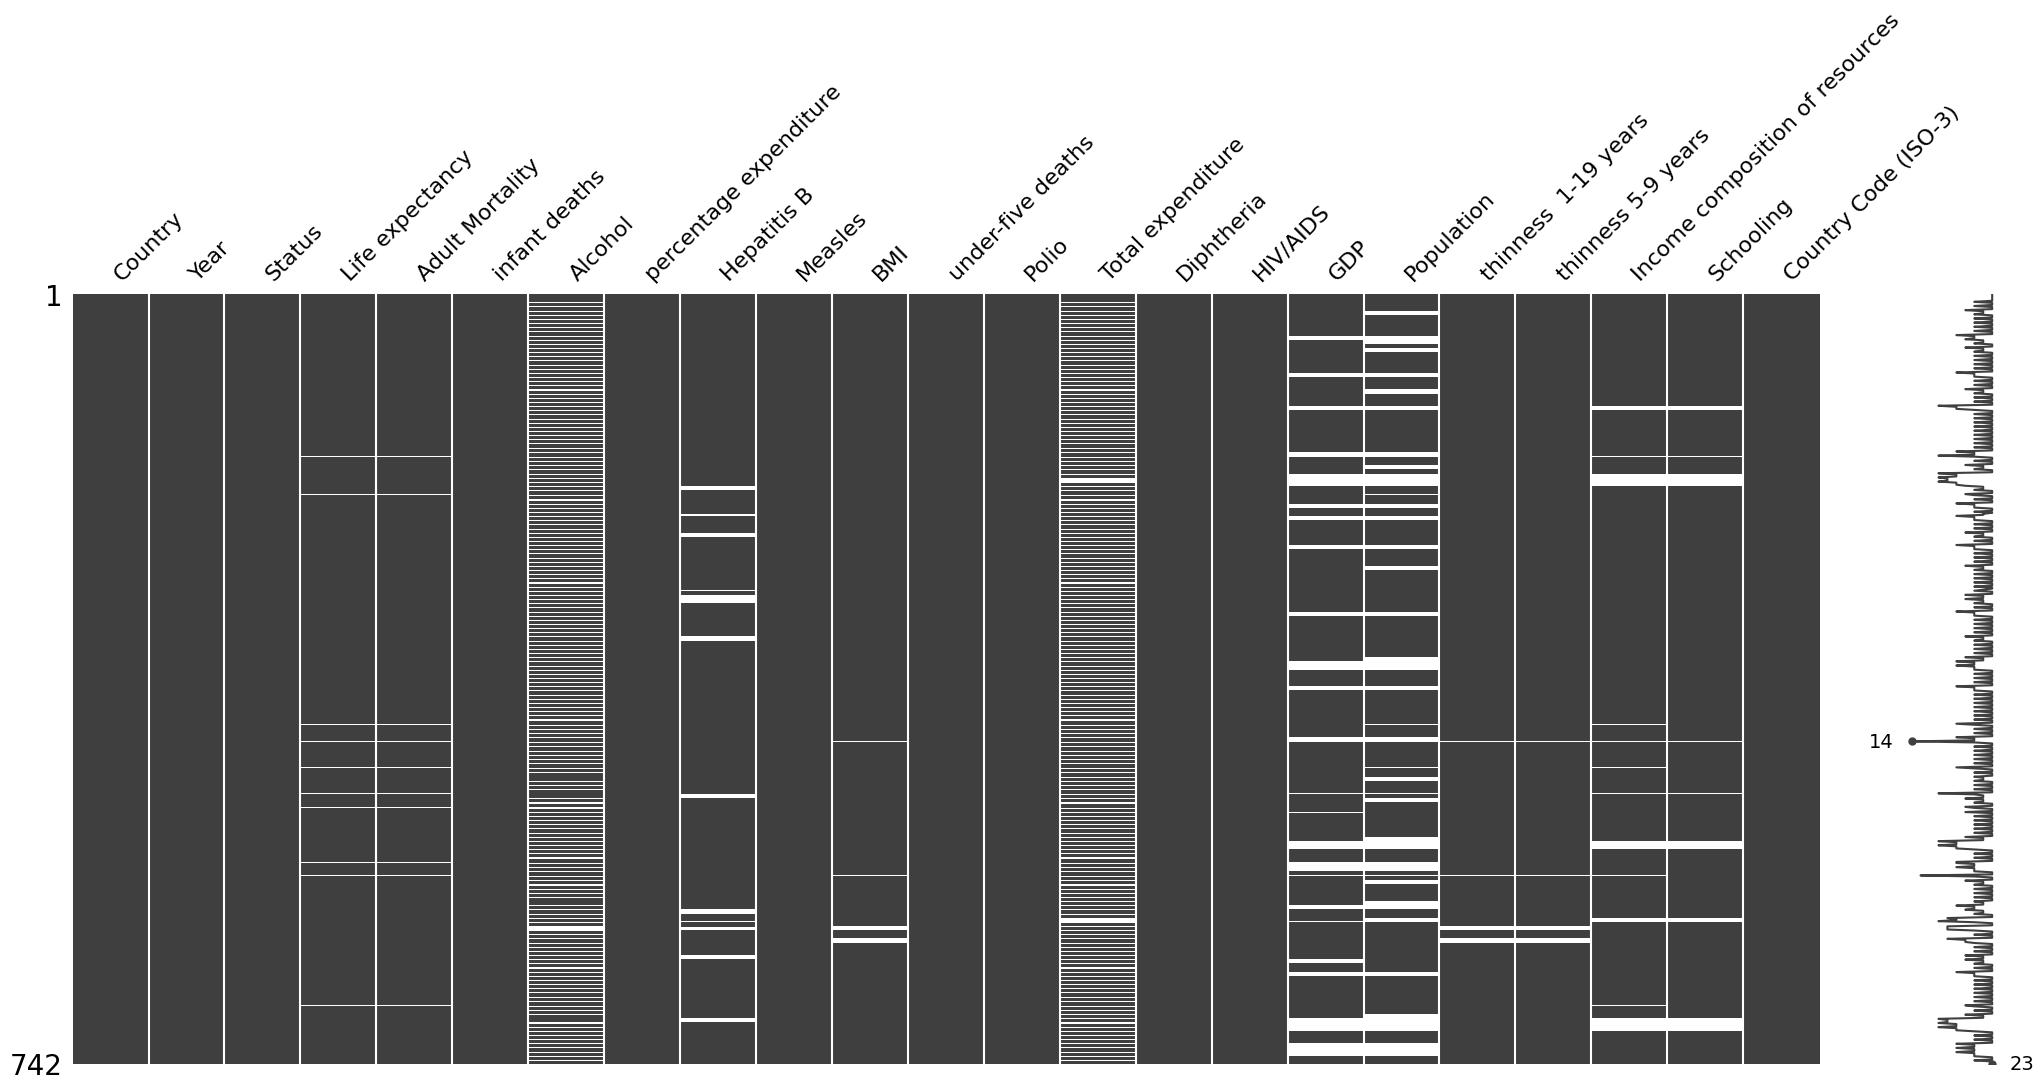

In [6]:
msno.matrix(df_2012)  # Visualizing existing and missing missing data in df_2012 using msno's nullity matrix

From basic visual inspection, we can see that there are numerous columns that have missing data. To deal with this, we can *drop* columns with missing values more than a certain threshold (for instance, 10), and *impute* all remaining columns with missing data. 

In [7]:
MISSING_THRESHOLD = 10  # Define threshold for missing values

''' Drop columns in df_2012 that have do not meet the missing value threshold '''
missing_counts = df_2012.isna().sum()  # Determine the count of missing values per column
cols_to_drop = missing_counts[missing_counts >= MISSING_THRESHOLD].index.tolist()  # Identify columns to drop based on threshold

# Drop the identified columns from df_2012, validating that it was successful
if cols_to_drop:
    print(f"Dropping {len(cols_to_drop)} columns with >={MISSING_THRESHOLD} missing values: {cols_to_drop}")
    df_2012_wrangled = df_2012.drop(columns=cols_to_drop, inplace=False)
else:
    print(f"No columns have {MISSING_THRESHOLD} or more missing values.")

''' Then, impute the remaining missing values with the mean of their respective columns '''
for feature_name in df_2012_wrangled.columns:
    if df_2012_wrangled[feature_name].isna().any():  # Check if there are missing values in the column
        feature_meanval = df_2012_wrangled[feature_name].mean()  # Calculate the mean of the column
        df_2012_wrangled[feature_name].fillna(feature_meanval, inplace=True)  # Impute missing values with the mean

Dropping 12 columns with >=10 missing values: ['Life expectancy', 'Adult Mortality', 'Alcohol', 'Hepatitis B', 'BMI', 'Total expenditure', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


To validate that we successfully cleaned the dataframe of all missing values, we can print the total count.

In [8]:
print("Total missing values after cleaning:", df_2012_wrangled.isna().sum().sum())  # Get missing values from all columns

Total missing values after cleaning: 0


In [9]:
# TESTING ONLY
df_2012_wrangled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 742 non-null    object 
 1   Year                    742 non-null    int64  
 2   Status                  742 non-null    object 
 3   infant deaths           742 non-null    int64  
 4   percentage expenditure  742 non-null    float64
 5   Measles                 742 non-null    int64  
 6   under-five deaths       742 non-null    int64  
 7   Polio                   742 non-null    float64
 8   Diphtheria              742 non-null    float64
 9   HIV/AIDS                742 non-null    float64
 10  Country Code (ISO-3)    742 non-null    object 
dtypes: float64(4), int64(4), object(3)
memory usage: 63.9+ KB


## Problem 6 - Seperating Data and Standardizing

Now, we can seperate the wrangled dataframe into three seperate dataframes: **ID** (country), **Categorical**, and **Numerical**.

In [10]:
# Create a new dataframe for only IDs, dropping duplicates and resetting the index to ensure proper behavior
df_2012_wrangled_id = df_2012_wrangled[['Country', 'Country Code (ISO-3)']].copy().drop_duplicates().reset_index(drop=True)

# Create a new dataframe for Categorical data only (All objects excluding Country and Country Code)
categorical_columns_df_2012 = [col for col in df_2012_wrangled.columns if \
    df_2012_wrangled[col].dtype == 'object' and col != 'Country Code (ISO-3)' and col != 'Country']
df_2012_wrangled_categorical = df_2012_wrangled[categorical_columns_df_2012].copy().reset_index(drop=True)

# Create a new dataframe for numerical data only
numerical_columns_df_2012 = [col for col in df_2012_wrangled.columns if df_2012_wrangled[col].dtype != 'object']
df_2012_wrangled_numerical = df_2012_wrangled[numerical_columns_df_2012].copy().reset_index(drop=True)

# Verifying columns in each new dataframe
print("ID DataFrame Columns:", df_2012_wrangled_id.columns.tolist())
print("Categorical DataFrame Columns:", df_2012_wrangled_categorical.columns.tolist())
print("Numerical DataFrame Columns:", df_2012_wrangled_numerical.columns.tolist())

ID DataFrame Columns: ['Country', 'Country Code (ISO-3)']
Categorical DataFrame Columns: ['Status']
Numerical DataFrame Columns: ['Year', 'infant deaths', 'percentage expenditure', 'Measles', 'under-five deaths', 'Polio', 'Diphtheria', 'HIV/AIDS']


Now, we can standardize the seperated numerical data to ensure consistency and equal weights.

In [11]:
# Instantiating a standard scaler and applying it to the numerical data
df_2012_scaler = StandardScaler()  # Initialize the standardizer
df_2012_wrangled_numerical_scaled = df_2012_scaler.fit_transform(df_2012_wrangled_numerical)  # Fit and transform the numerical data
df_2012_wrangled_numerical_scaled = pd.DataFrame(df_2012_wrangled_numerical_scaled, columns=numerical_columns_df_2012)  # Convert back to a DataFrame

# Validating the standardized numerical data (mean =~ 0, std =~ 1)
print(f"Numerical DataFrame after Standardization:\n{df_2012_wrangled_numerical_scaled.describe()}")

Numerical DataFrame after Standardization:
               Year  infant deaths  percentage expenditure     Measles  \
count  7.420000e+02   7.420000e+02            7.420000e+02  742.000000   
mean   9.702870e-14   7.182036e-18           -6.224431e-17    0.000000   
std    1.000675e+00   1.000675e+00            1.000675e+00    1.000675   
min   -1.342897e+00  -2.777614e-01           -3.363556e-01   -0.197932   
25%   -4.435924e-01  -2.777614e-01           -3.363556e-01   -0.197932   
50%   -4.435924e-01  -2.552320e-01           -3.142366e-01   -0.196488   
75%    4.557124e-01  -7.499679e-02           -1.264809e-01   -0.168821   
max    1.355017e+00   1.211341e+01            8.830570e+00   11.668221   

       under-five deaths         Polio    Diphtheria      HIV/AIDS  
count       7.420000e+02  7.420000e+02  7.420000e+02  7.420000e+02  
mean        9.576048e-18 -6.703233e-17 -1.053365e-16  4.788024e-18  
std         1.000675e+00  1.000675e+00  1.000675e+00  1.000675e+00  
min        -2.

## Problem 7 - $k$-Means Clustering

Using this standardized numerical data, we can explore clustering the data using $k$-Means. To find the optimal $k$ value (how many clusters we would like), we can firstly visually analyze using an **Elbow plot**.

In [12]:
k_vals = range(2, 11)  # Range of k value to test (2 to 10)
inertia_vals = []  # To store inertia values for each k

for k in k_vals:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Initialize k-Means with current k
    kmeans.fit(df_2012_wrangled_numerical_scaled)  # Fit k-Means to the standardized numerical data
    inertia_vals.append(kmeans.inertia_)  # Append the inertia value for this k
    
# Plotting the Elbow Plot to visualize inertia vs. k values
elbow_fig = go.Figure(data=go.Scatter(x=list(k_vals), y=inertia_vals, mode='lines+markers'))
elbow_fig.update_layout(
    title='Elbow Plot for k-Means Clustering',
    xaxis_title='Number of Clusters (k)',
    yaxis_title='Inertia',
    xaxis=dict(dtick=1)
)
elbow_fig.show()

From the elbow curve, we can see the "elbow" (where the sharp bend begins) is around $k = 4$, suggesting that diminising returns occur beyond this point. To further validate this $k$, we can also use a **Silhouette Analysis**.

In [13]:
silhouette_scores = []  # To store silhouette scores for each k

for k in k_vals:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Initialize k-Means with current k
    cluster_labels = kmeans.fit_predict(df_2012_wrangled_numerical_scaled)  # Fit and predict cluster labels
    silhouette_avg = silhouette_score(df_2012_wrangled_numerical_scaled, cluster_labels)  # Calculate silhouette score
    silhouette_scores.append(silhouette_avg)  # Append the silhouette score for this k
    
# Plotting the Silhouette Analysis results
silhouette_fig = go.Figure(data=go.Scatter(x=list(k_vals), y=silhouette_scores, mode='lines+markers'))
silhouette_fig.update_layout(
    title='Silhouette Analysis for k-Means Clustering',
    xaxis_title='Number of Clusters (k)',
    yaxis_title='Silhouette Score',
    xaxis=dict(dtick=1)
)
silhouette_fig.show()

According to the Silhouette Analysis, we are informed that clusters are well seperated from 2-4, facing a sharp decline after 4. This aligns with our elbow plot results, indicating strongest value for $k$ is $k=4$.

Now, we can create and fit a k-Means clustering model with $k=4$ on the standardized numerical data.

In [14]:
OPTIMAL_K = 4  # Based on previous analyses

# Create and fit the final k-Means model with the optimal k
kmeans_2012_final = KMeans(n_clusters=OPTIMAL_K, random_state=42)  # Initialize k-Means with optimal k
kmeans_2012_final.fit(df_2012_wrangled_numerical_scaled)  # Fit the k-Means model to the standardized numerical data

# Create a copy of the original dataframe to store cluster labels for result validation
df_2012_wrangled_copy = df_2012_wrangled.copy()
df_2012_wrangled_copy['Cluster'] = kmeans_2012_final.predict(df_2012_wrangled_numerical_scaled)

# Print the cluster counts to validate clustering results
print(df_2012_wrangled_copy['Cluster'].value_counts())

# Print the first few countries from each cluster
for c in sorted(df_2012_wrangled_copy['Cluster'].unique()):
    countries = df_2012_wrangled.loc[df_2012_wrangled_copy['Cluster'] == c, 'Country']
    print(f"\nCluster {c} ({len(countries)} countries):")
    print(", ".join(countries.head(10)))  # print first 10 for brevity

Cluster
1    575
0    126
2     27
3     14
Name: count, dtype: int64

Cluster 0 (126 countries):
Afghanistan, Afghanistan, Afghanistan, Angola, Angola, Angola, Angola, Benin, Burkina Faso, Côte d'Ivoire

Cluster 1 (575 countries):
Afghanistan, Albania, Albania, Albania, Albania, Algeria, Algeria, Algeria, Algeria, Antigua and Barbuda

Cluster 2 (27 countries):
Australia, Australia, Australia, Austria, Austria, Belgium, Canada, Canada, Denmark, Denmark

Cluster 3 (14 countries):
China, Congo, Democratic Republic of the, Congo, Democratic Republic of the, Congo, Democratic Republic of the, India, India, India, India, Nigeria, Nigeria


In addition to basic printing validation, we can also (approximately) plot the clusters to better visualization. A limitation to this is that we will need to reduce the dimensionality down to 2D, however the visualization could still prove to be beneficial.

In [15]:
# Since we cannot visualize in higher dimensions easily, we can use PCA to reduce to 2D for plotting
pca_2012 = PCA(n_components=2)  # Initialize PCA to reduce to 2 components
df_2012_numerical_pca_components = pca_2012.fit_transform(df_2012_wrangled_numerical_scaled)  # Get the principle components
df_2012_numerical_plot = pd.DataFrame({  # Get a dataframe for plotting
    'PC1': df_2012_numerical_pca_components[:, 0],
    'PC2': df_2012_numerical_pca_components[:, 1],
    'Cluster': df_2012_wrangled_copy['Cluster'],
    'Country': df_2012_wrangled['Country Code (ISO-3)'],
})

# Plotting the clusters in 2D PCA space (adding each point to the plot in the specified color for its cluster)
cluster_plot_fig = go.Figure()
for c in sorted(df_2012_numerical_plot['Cluster'].unique()):
    cluster_data = df_2012_numerical_plot[df_2012_numerical_plot['Cluster'] == c]
    cluster_plot_fig.add_trace(go.Scatter(
        x=cluster_data['PC1'],
        y=cluster_data['PC2'],
        mode='markers',
        name=f'Cluster {c}',
        text=cluster_data['Country'],
        hoverinfo='text+x+y'
    ))
cluster_plot_fig.update_layout(
    title='k-Means Clustering Results (PCA Reduced to 2D)',
    xaxis_title='Principal Component 1',
    yaxis_title='Principal Component 2'
)
cluster_plot_fig.show()

## Problem 8 - World Map Cluster Choropleth Plot

Using these results (and the corresponding ISO-3 country codes), we can create a World Map Cluster Choropleth Plot using Plotly for a better geographical visualization.

In [16]:
df_2012_wrangled_copy['Cluster'] = df_2012_wrangled_copy['Cluster'].astype(str)  # Convert to strings to make plotly happy

# Defining and showing a World Map Cluster Choropleth Plot using Plotly Express
wmc_fig = px.choropleth(
    data_frame=df_2012_wrangled_copy,  # Dataframe to use
    locations='Country Code (ISO-3)',  # Column with ISO-3 country codes
    color='Cluster',  # Column to color by (Cluster labels)
    hover_name='Country',  # Column to show on hover
    color_discrete_sequence=px.colors.qualitative.Set2,  # Color sequence for clusters (2 looks better than 1)   
)
wmc_fig.update_layout(
    title='World Map Cluster Choropleth Plot (2012 Data)',
    geo=dict(showframe=True, showcoastlines=True, projection_type='natural earth', landcolor='lightgray'),  # Setting geographical layout
    margin=dict(l=0, r=0, t=60, b=20)  # Adjusting margins
)
wmc_fig.show()

### Narrative Description

This plot shows us the results from our $k$-means clustering "model", placing each of the $4$ clusters (0-3) on a world map using their corresponding ISO-3 Country Codes. The greyed-out areas indicate that there was not sufficient data to predict them. Countries grouped together share similar attributes as reflected in the dataset, comparing similarities in infant deaths, percentage expenditure, measles, under-five deaths, Polio, Diphtheria, and HIV/AIDS. One observation from the map is that North/South American is almost entirely in cluster 1, suggesting similar life expentency metrics. Additionally, Africa and the Middle East hold all cluster 0s, suggesting that life expentency metrics are significantly different in these areas than others.

## Problem 8 - Covariance

To help us understand the structure of the feature data, we can create and visualize a **covarance matrix**.

In [ ]:
# TODO